In [1]:
from scipy.stats import mannwhitneyu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from src.preprocessing import load_and_preprocess

asv, asv_clr, meta, taxa = load_and_preprocess()
print(f"Ready: {asv_clr.shape}, metadata: {meta.shape}")

Ready: (129, 41), metadata: (41, 1)


In [2]:
cd_samples = meta[meta['Class'] == 'CD'].index
control_samples = meta[meta['Class'] == 'Control'].index

print(f"CD samples: {len(cd_samples)}")
print(f"Control samples: {len(control_samples)}")

CD samples: 21
Control samples: 20


In [3]:
def chao1(counts):
    """Calculate Chao1 richness estimate for a single sample's counts."""
    observed = (counts > 0).sum()
    singletons = (counts == 1).sum()
    doubletons = (counts == 2).sum()
    if doubletons == 0:
        return observed + (singletons * (singletons - 1)) / 2
    return observed + (singletons ** 2) / (2 * doubletons)

chao1_values = asv.apply(chao1, axis=0)
print(chao1_values.head())

206700    29.0
206701    10.0
206702     7.0
206703    88.0
206704    86.0
dtype: float64


In [4]:
chao1_cd = chao1_values[cd_samples]
chao1_control = chao1_values[control_samples]

stat, pval = mannwhitneyu(chao1_cd, chao1_control)

print(f"CD median Chao1: {chao1_cd.median():.1f}")
print(f"Control median Chao1: {chao1_control.median():.1f}")
print(f"Mann-Whitney p-value: {pval:.4f}")

CD median Chao1: 63.0
Control median Chao1: 76.5
Mann-Whitney p-value: 0.0050


In [5]:
def shannon(counts):
    """Calculate Shannon diversity index for a single sample's counts."""
    counts = counts[counts > 0]  # only consider present species
    proportions = counts / counts.sum()
    return -(proportions * np.log(proportions)).sum()

shannon_values = asv.apply(shannon, axis=0)

shannon_cd = shannon_values[cd_samples]
shannon_control = shannon_values[control_samples]

stat, pval = mannwhitneyu(shannon_cd, shannon_control)

print(f"CD median Shannon: {shannon_cd.median():.3f}")
print(f"Control median Shannon: {shannon_control.median():.3f}")
print(f"Mann-Whitney p-value: {pval:.4f}")

CD median Shannon: 2.587
Control median Shannon: 2.907
Mann-Whitney p-value: 0.1629


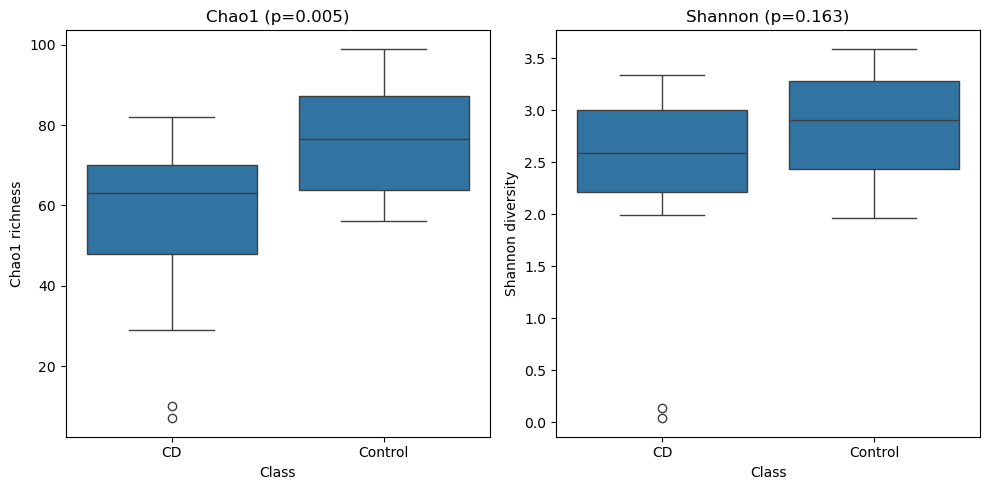

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Chao1 boxplot
sns.boxplot(x=meta['Class'], y=chao1_values, ax=axes[0])
axes[0].set_title(f'Chao1 (p={mannwhitneyu(chao1_cd, chao1_control)[1]:.3f})')
axes[0].set_ylabel('Chao1 richness')

# Shannon boxplot
sns.boxplot(x=meta['Class'], y=shannon_values, ax=axes[1])
axes[1].set_title(f'Shannon (p={mannwhitneyu(shannon_cd, shannon_control)[1]:.3f})')
axes[1].set_ylabel('Shannon diversity')
plt.tight_layout()
plt.savefig('../figures/alpha_diversity.png', dpi=150)
plt.show()